<center> <h1 style="background-color:orange; color:white"><br>Exploratory Data Analysis<br></h1></center>

# `Problem Statement:`
We have used Cars dataset from kaggle  with features including make, model, year, engine, and other properties of the car used to predict its price.

## `Importing the necessary libraries`





In [2]:
import pandas as pd
import numpy as np
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
%matplotlib inline 
sns.set(color_codes=True)
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

## `Load the dataset into dataframe`

In [36]:
## load the csv file 
df = pd.read_csv("D:\\DOWNLOAD FILES\\Cars_data.csv")

In [4]:
## print the head of the dataframe

print(df.head())

  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performance      Compact         C

Now we observe the each features present in the dataset.<br>

 `Make:` The Make feature is the company name of the Car.<br>
`Model:` The Model feature is the model or different version of Car models.<br>
`Year:`  The year describes the model has been launched.<br>
`Engine Fuel Type:` It defines the Fuel type of the car model.<br>
`Engine HP:` It's say the Horsepower that refers to the power an engine produces.<br>
`Engine Cylinders:` It define the nos of cylinders in present in the engine.<br>
`Transmission Type:` It is the type of feature that describe about the car transmission type i.e Mannual or automatic.<br>
`Driven_Wheels:` The type of wheel drive.<br>
`No of doors:` It defined nos of doors present in the car.<br>
`Market Category:` This features tells about the type of car or which category the car belongs. <br>
`Vehicle Size:` It's say about the about car size.<br>
`Vehicle Style:` The feature is all about the style that belongs to car.<br>
`highway MPG:` The average a car will get while driving on an open stretch of road without stopping or starting, typically at a higher speed.<br>
`city mpg:` City MPG refers to driving with occasional stopping and braking.<br>
`Popularity:` It can refered to rating of that car or popularity of car.<br>
`MSRP:` The price of that car.







## `Check the datatypes`

In [35]:
# Get the datatypes of each columns number of records in each column.
print(df.dtypes)


Year           float64
HP             float64
Cylinders      float64
highway MPG    float64
city mpg       float64
Price          float64
dtype: object


## `Dropping irrevalent columns`

If we consider all columns present in the dataset then unneccessary columns will impact on the model's accuracy.<br>
Not all the columns are important to us in the given dataframe, and hence we would drop the columns that are irrevalent to us. It would reflect our model's accucary so we need to drop them. Otherwise it will affect our model.


The list cols_to_drop contains the names of the cols that are irrevalent, drop all these cols from the dataframe.


`cols_to_drop = ["Engine Fuel Type", "Market Category", "Vehicle Style", "Popularity", "Number of Doors", "Vehicle Size"]`

These features are not neccessary to obtain the model's accucary. It does not contain any relevant information in the dataset. 

In [6]:
# initialise cols_to_drop

cols_to_drop = ["Engine Fuel Type", "Market Category", "Vehicle Style", "Popularity", "Number of Doors", "Vehicle Size"]

In [7]:
# drop the irrevalent cols and print the head of the dataframe
df = df.drop(columns=cols_to_drop)

# print df head

print(df.head())

  Make       Model  Year  Engine HP  Engine Cylinders Transmission Type  \
0  BMW  1 Series M  2011      335.0               6.0            MANUAL   
1  BMW    1 Series  2011      300.0               6.0            MANUAL   
2  BMW    1 Series  2011      300.0               6.0            MANUAL   
3  BMW    1 Series  2011      230.0               6.0            MANUAL   
4  BMW    1 Series  2011      230.0               6.0            MANUAL   

      Driven_Wheels  highway MPG  city mpg   MSRP  
0  rear wheel drive           26        19  46135  
1  rear wheel drive           28        19  40650  
2  rear wheel drive           28        20  36350  
3  rear wheel drive           28        18  29450  
4  rear wheel drive           28        18  34500  


## `Renaming the columns`

Now, Its time for renaming the feature to useful feature name. It will help to use them in model training purpose.<br>

We have already dropped the unneccesary columns, and now we are left with useful columns. One extra thing that we would do is to rename the columns such that the name clearly represents the essence of the column.

The given dict represents (in key value pair) the previous name, and the new name for the dataframe columns

In [8]:
# rename cols 


In [43]:
rename_cols = {
    'Make': 'Brand',
    'Model': 'Model',
    'Year': 'Year',
    'Engine HP': 'HP',
    'Engine Cylinders': 'Cylinders',
    'Transmission Type': 'Transmission',
    'MSRP':'Price',
}

# Rename the columns
df = df.rename(columns=rename_cols)

# Print the head of the DataFrame to verify the changes
print(df.head())

  Brand       Model  Year             Engine Fuel Type     HP  Cylinders  \
0   BMW  1 Series M  2011  premium unleaded (required)  335.0        6.0   
1   BMW    1 Series  2011  premium unleaded (required)  300.0        6.0   
2   BMW    1 Series  2011  premium unleaded (required)  300.0        6.0   
3   BMW    1 Series  2011  premium unleaded (required)  230.0        6.0   
4   BMW    1 Series  2011  premium unleaded (required)  230.0        6.0   

  Transmission     Driven_Wheels  Number of Doors  \
0       MANUAL  rear wheel drive              2.0   
1       MANUAL  rear wheel drive              2.0   
2       MANUAL  rear wheel drive              2.0   
3       MANUAL  rear wheel drive              2.0   
4       MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performance      Compact         Coupe   
1                     Luxury,Performance      Compact   Convertible   
2          

## `Dropping the duplicate rows`

There are many rows in the dataframe which are duplicate, and hence they are just repeating the information. Its better if we remove these rows as they don't add any value to the dataframe. 

For given data, we would like to see how many rows were duplicates. For this, we will count the number of rows, remove the dublicated rows, and again count the number of rows.

In [10]:
print (df.shape)

(11914, 10)


In [41]:
# drop the duplicated rows
df = df.drop_duplicates()

# print head of df
print (df.head())


  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performance      Compact         C

In [12]:
# Count Number of rows after deleting duplicated rows
df.count()
print(df.shape)


(10925, 10)


## `Dropping the null or missing values`

Missing values are usually represented in the form of Nan or null or None in the dataset.

Finding whether we have null values in the data is by using the isnull() function.

There are many values which are missing, in pandas dataframe these values are reffered to as np.nan. We want to deal with these values beause we can't use nan values to train models. Either we can remove them to apply some strategy to replace them with other values.

To keep things simple we will be dropping nan values

In [13]:
# check for nan values in each columns

nan_counts = df.isna().sum()
nan_counts


Brand             0
Model             0
Year              0
HP               69
Cylinders        30
Transmission      0
Driven_Wheels     0
highway MPG       0
city mpg          0
Price             0
dtype: int64

As we can see that the HP and Cylinders have null values of 69 and 30. As these null values will impact on models' accuracy. So to avoid the impact we will drop the these values. As these values are small camparing with dataset  that will not impact any major affect on model accuracy so we will drop the values.

In [14]:
# drop missing values
df = df.dropna()

  

In [15]:
# Make sure that missing values are removed
# check number of nan values in each col again
nan_counts_after_dropping = df.isna().sum()
nan_counts_after_dropping

Brand            0
Model            0
Year             0
HP               0
Cylinders        0
Transmission     0
Driven_Wheels    0
highway MPG      0
city mpg         0
Price            0
dtype: int64

In [16]:
#Describe statistics of df

df = df.describe()
df

,Year,HP,Cylinders,highway MPG,city mpg,Price
count,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,1.082700e+04
mean,2010.896370,254.553062,5.691604,26.308119,19.327607,4.249325e+04
std,7.029534,109.841537,1.768551,7.504652,6.643567,6.229451e+04
min,1990.000000,55.000000,0.000000,12.000000,7.000000,2.000000e+03
25%,2007.000000,173.000000,4.000000,22.000000,16.000000,2.197250e+04
50%,2015.000000,240.000000,6.000000,25.000000,18.000000,3.084500e+04
75%,2016.000000,303.000000,6.000000,30.000000,22.000000,4.330000e+04
max,2017.000000,1001.000000,16.000000,354.000000,137.000000,2.065902e+06


## `Removing outliers`

Sometimes a dataset can contain extreme values that are outside the range of what is expected and unlike the other data. These are called outliers and often machine learning modeling and model skill in general can be improved by understanding and even removing these outlier values.

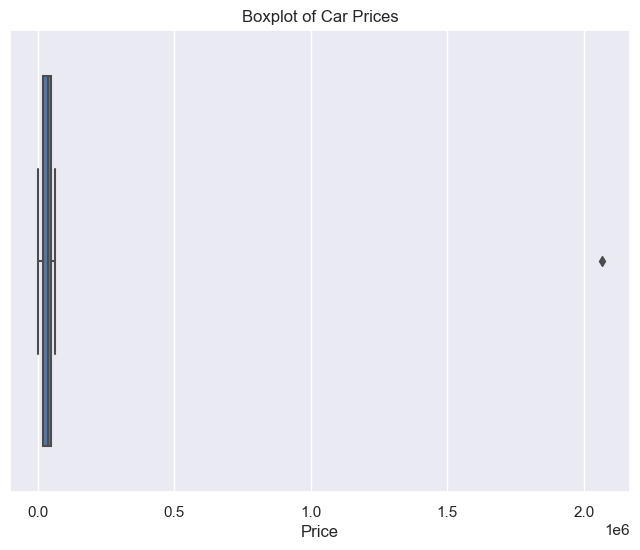

In [17]:
## Plot a boxplot for 'Price' column in dataset. 

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Price'])

# Set the title and labels
plt.title('Boxplot of Car Prices')
plt.xlabel('Price')

# Show the plot
plt.show()

### **`Observation:`**<br>

Here as you see that we got some values near to 1.5 and 2.0 . So these values are called outliers. Because there are away from the normal values.
Now we have detect the outliers of the feature of Price. Similarly we will checking of anothers features.

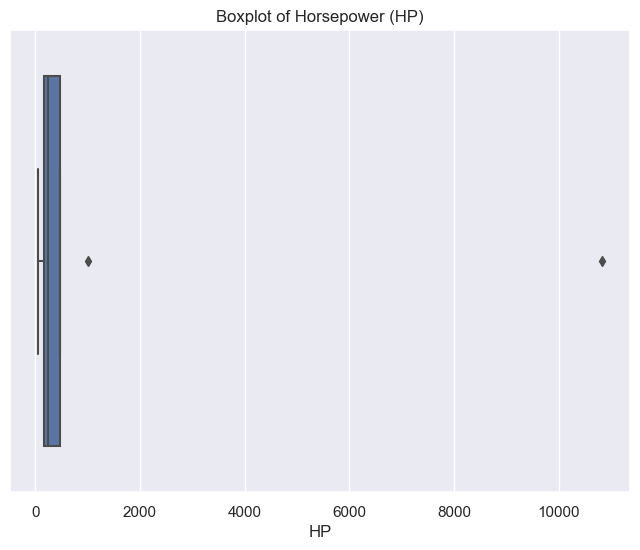

In [18]:
## PLot a boxplot for 'HP' columns in dataset

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['HP'])

# Set the title and labels
plt.title('Boxplot of Horsepower (HP)')
plt.xlabel('HP')

# Show the plot
plt.show()

### **`Observation:`**<br>
Here boxplots show the proper distribution of of 25 percentile and 75 percentile of the feature of HP.

print all the columns which are of int or float datatype in df. 

Hint: Use loc with condition

In [19]:
# print all the columns which are of int or float datatype in df.

numeric_columns = df.select_dtypes(include=['int', 'float']).columns

# Print the list of numeric columns
print("Columns with int or float data types:")
print(numeric_columns)

Columns with int or float data types:
Index(['Year', 'HP', 'Cylinders', 'highway MPG', 'city mpg', 'Price'], dtype='object')


### `Save the column names of the above output in variable list named 'l'`


In [20]:
# save column names of the above output in variable list
L=numeric_columns


## **`Outliers removal techniques - IQR Method`**
 

**Here comes cool Fact for you!**

IQR is the first quartile subtracted from the third quartile; these quartiles can be clearly seen on a box plot on the data.

- Calculate IQR  and give a suitable threshold to remove the outliers and save this new dataframe into df2.

Let us help you to decide threshold: Outliers in this case are defined as the observations that are below (Q1 − 1.5x IQR) or above (Q3 + 1.5x IQR)

In [21]:
## define Q1 and Q2
# Q1 = 
# Q3 = 
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# # define IQR (interquantile range) 
# IQR =    

# # define df2 after removing outliers
# df2 = 
df2 = df[~((df[numeric_columns] < lower_bound) | (df[numeric_columns] > upper_bound)).any(axis=1)]
print("Original DataFrame shape:", df.shape)
print("New DataFrame shape after removing outliers:", df2.shape)

Original DataFrame shape: (8, 6)
New DataFrame shape after removing outliers: (5, 6)


In [22]:
numeric_columns = df.select_dtypes(include=['int', 'float']).columns

# Calculate Q1, Q3, and IQR for each numeric column
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Define thresholds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to remove outliers
df2 = df[~((df[numeric_columns] < lower_bound) | (df[numeric_columns] > upper_bound)).any(axis=1)]

# Print the shape of the new DataFrame to confirm changes
print("Original DataFrame shape:", df.shape)
print("New DataFrame shape after removing outliers:", df2.shape)


Original DataFrame shape: (8, 6)
New DataFrame shape after removing outliers: (5, 6)


In [23]:
# find the shape of df & df2


print("Shape of original DataFrame (df):", df.shape)

# Print the shape of df2
print("Shape of DataFrame after removing outliers (df2):", df2.shape)

Shape of original DataFrame (df): (8, 6)
Shape of DataFrame after removing outliers (df2): (5, 6)


In [24]:
# find unique values and there counts in each column in df using value counts function.

# for i in df.columns:
#     print ("--------------- %s ----------------" % i)
#     # code here
for i in df.columns:
    print("--------------- %s ----------------" % i)
    print(df[i].value_counts())
    print("\n")

--------------- Year ----------------
10827.000000    1
2010.896370     1
7.029534        1
1990.000000     1
2007.000000     1
2015.000000     1
2016.000000     1
2017.000000     1
Name: Year, dtype: int64


--------------- HP ----------------
10827.000000    1
254.553062      1
109.841537      1
55.000000       1
173.000000      1
240.000000      1
303.000000      1
1001.000000     1
Name: HP, dtype: int64


--------------- Cylinders ----------------
6.000000        2
10827.000000    1
5.691604        1
1.768551        1
0.000000        1
4.000000        1
16.000000       1
Name: Cylinders, dtype: int64


--------------- highway MPG ----------------
10827.000000    1
26.308119       1
7.504652        1
12.000000       1
22.000000       1
25.000000       1
30.000000       1
354.000000      1
Name: highway MPG, dtype: int64


--------------- city mpg ----------------
10827.000000    1
19.327607       1
6.643567        1
7.000000        1
16.000000       1
18.000000       1
22.000000   

## `Visualising Univariate Distributions`

We will use seaborn library to visualize eye catchy univariate plots. 

Do you know? you have just now already explored one univariate plot. guess which one? Yeah its box plot.


### `Histogram & Density Plots`

Histograms and density plots show the frequency of a numeric variable along the y-axis, and the value along the x-axis. The ```sns.distplot()``` function plots a density curve. Notice that this is aesthetically better than vanilla ```matplotlib```.

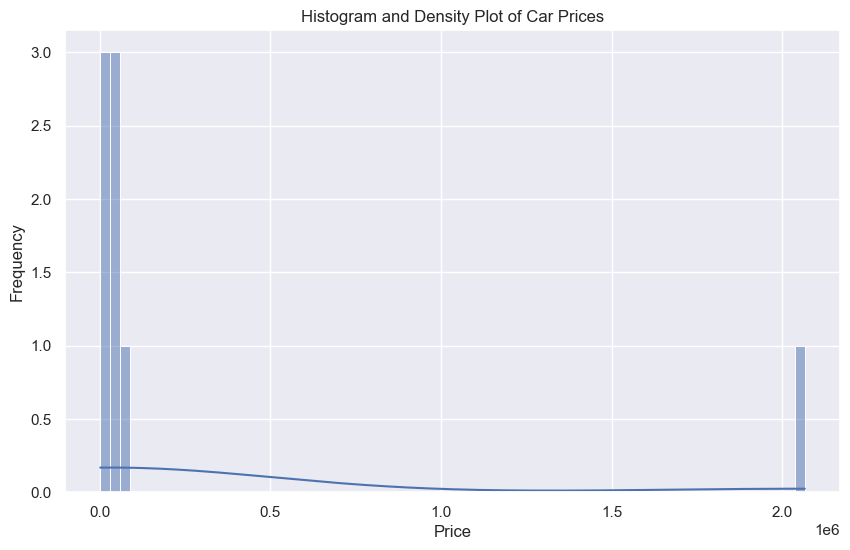

In [25]:
#ploting distplot for variable HP
plt.figure(figsize=(10, 6))

# Histogram with density curve
sns.histplot(df['Price'], kde=True)

# Set plot labels and title
plt.title('Histogram and Density Plot of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Show the plot
plt.show()


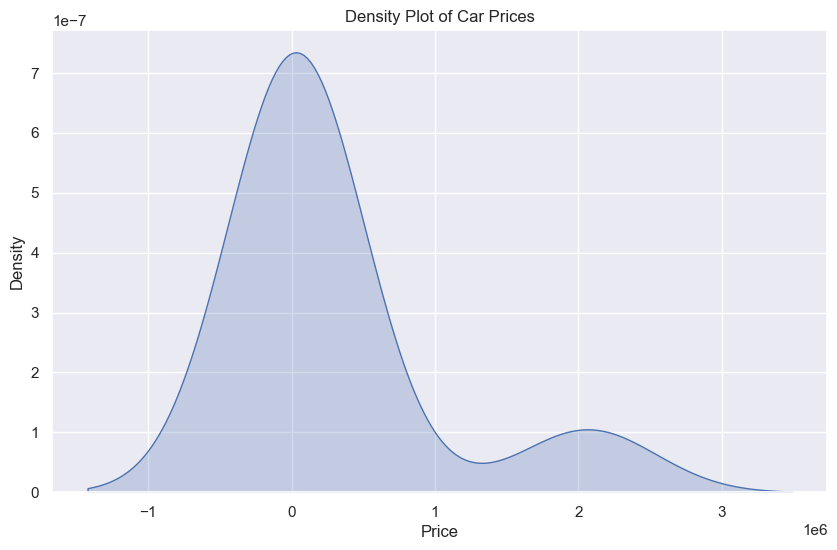

In [26]:
plt.figure(figsize=(10, 6))

# Density plot for the 'Price' column
sns.kdeplot(df['Price'], shade=True)

plt.title('Density Plot of Car Prices')
plt.xlabel('Price')
plt.ylabel('Density')

plt.show()


### **`Observation:`**
We plot the Histogram of feature HP with help of distplot in seaborn.<br> 
In this graph we can see that there is max values near at 200. similary we have also the 2nd highest value near 400 and so on. <br>
It represents the overall distribution of continuous data variables.<br>

Since seaborn uses matplotlib behind the scenes, the usual matplotlib functions work well with seaborn. For example, you can use subplots to plot multiple univariate distributions.
- Hint: use matplotlib subplot function

In [27]:
# plot all the columns present in list l together using subplot of dimention (2,3).


# c=0
# plt.figure(figsize=(15,10))
# for i in l:
#     # code here
# plt.show()


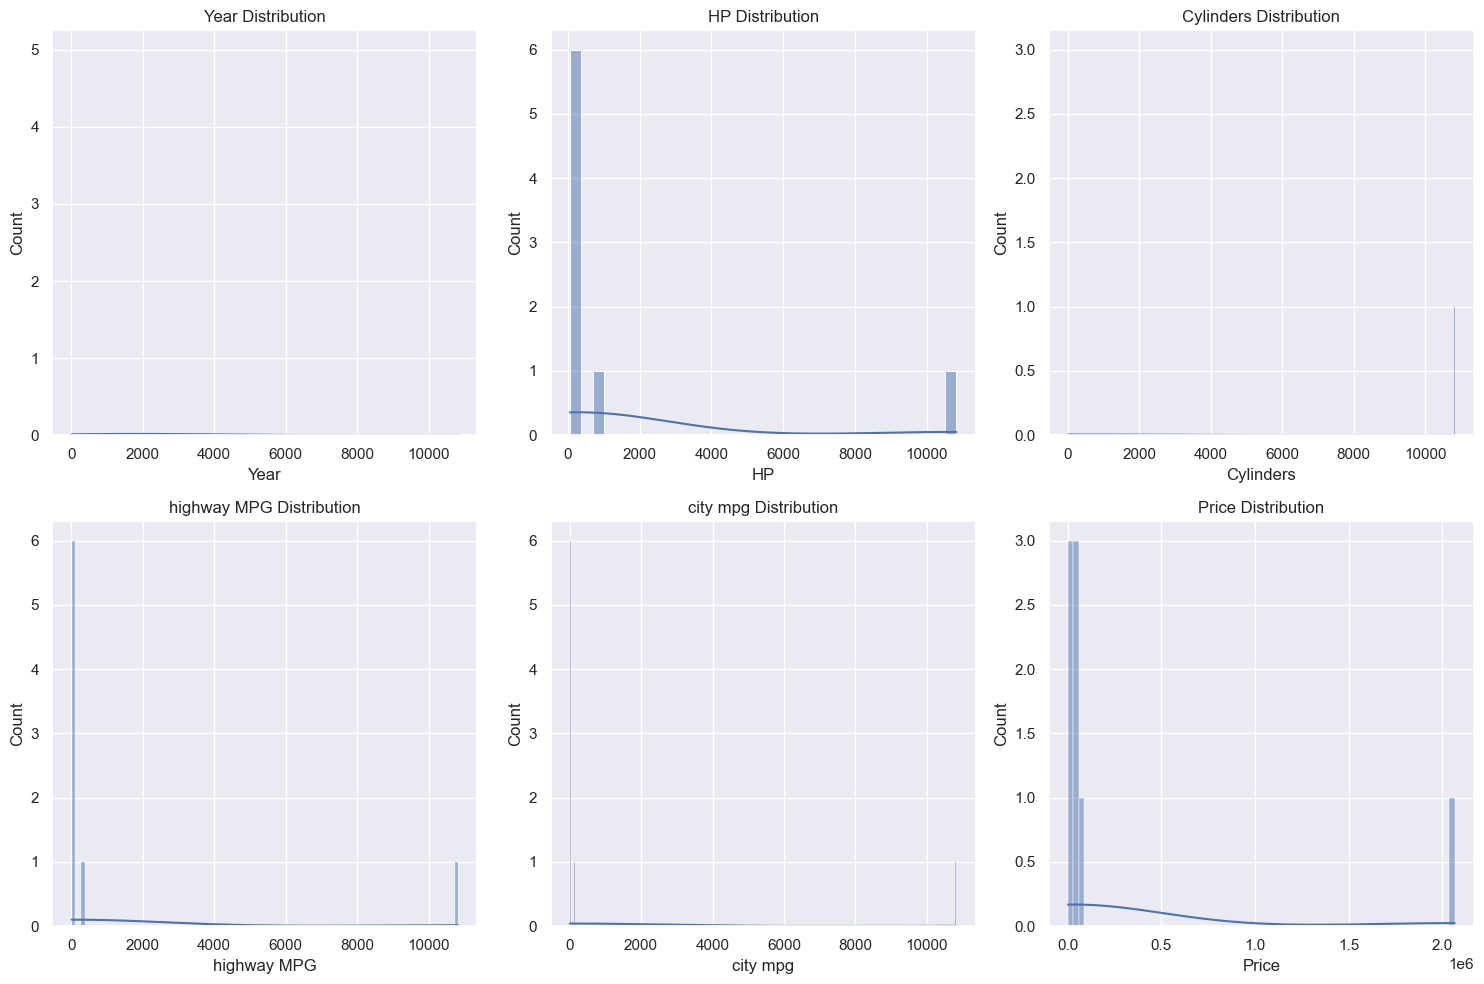

In [28]:
c = 0

# Create a figure with 2 rows and 3 columns
plt.figure(figsize=(15, 10))

# Loop through the list and create subplots
for i in L:
    plt.subplot(2, 3, c + 1)  # Create subplot at position (2 rows, 3 columns)
    sns.histplot(df[i], kde=True)  # Plot histogram with density curve
    plt.title(f'{i} Distribution')  # Set the title for each plot
    c += 1  # Increment subplot counter

# Show the plots
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## `Bar Chart Plots`


Plot a histogram depicting the make in X axis and number of cars in y axis. <br>

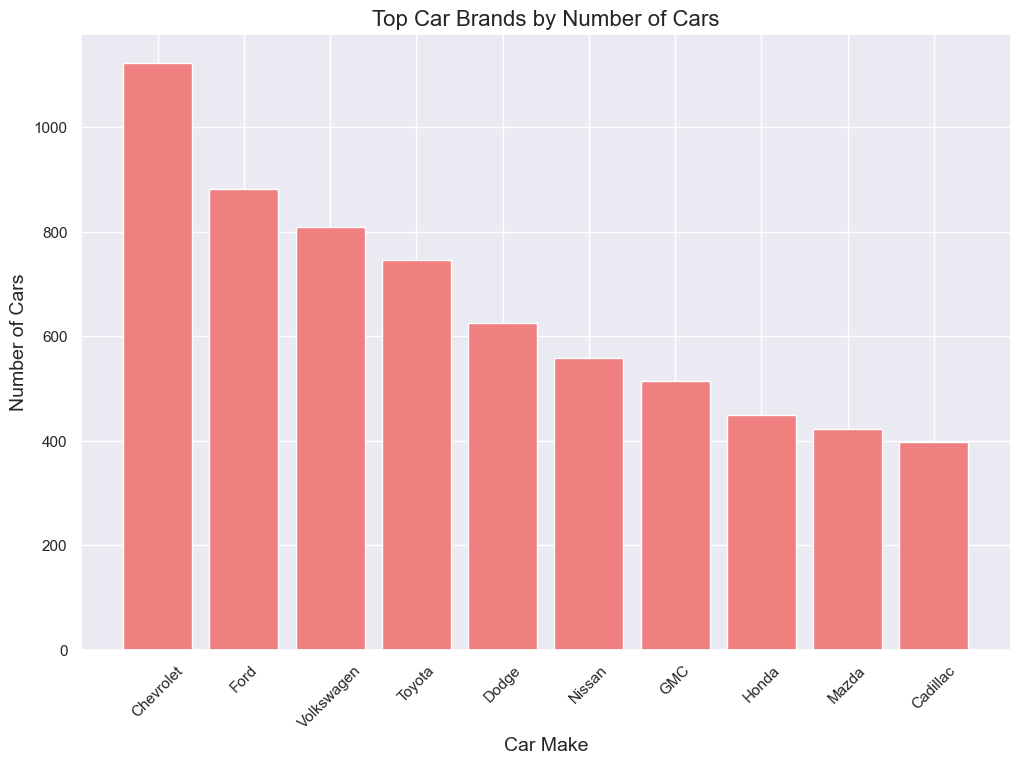

In [39]:
# plt.figure(figsize = (12,8))

# use nlargest and then .plot to get bar plot like below output
# Plot Title, X & Y label
top_makes = df['Make'].value_counts().nlargest(10)

# Plot a bar plot for the top car brands
plt.figure(figsize=(12, 8))
plt.bar(top_makes.index, top_makes.values, color='lightcoral')

# Set plot title and labels
plt.title('Top Car Brands by Number of Cars', fontsize=16)
plt.xlabel('Car Make', fontsize=14)
plt.ylabel('Number of Cars', fontsize=14)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()



### **`Observation:`**
In this plot we can see that we have plot the bar plot with the cars model and nos. of cars.

### `Count Plot`
A count plot can be thought of as a histogram across a categorical, instead of quantitative, variable.


 Plot a countplot for a variable Transmission vertically with hue as Drive mode

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'MANUAL'),
  Text(1, 0, 'AUTOMATIC'),
  Text(2, 0, 'AUTOMATED_MANUAL'),
  Text(3, 0, 'DIRECT_DRIVE'),
  Text(4, 0, 'UNKNOWN')])

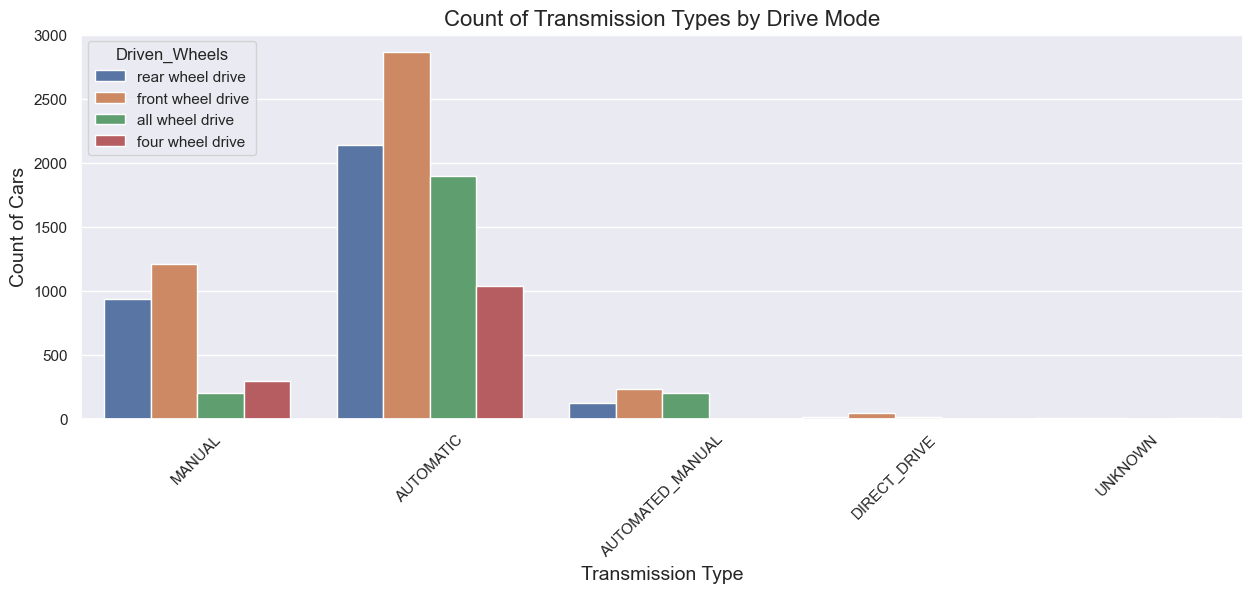

In [48]:
# plt.figure(figsize=(15,5))

# plot countplot on transmission and drive mode


plt.figure(figsize=(15, 5))

# Plot countplot for Transmission with hue as Drive Mode
sns.countplot(data=df, x='Transmission', hue='Driven_Wheels')

# Set plot title and labels
plt.title('Count of Transmission Types by Drive Mode', fontsize=16)
plt.xlabel('Transmission Type', fontsize=14)
plt.ylabel('Count of Cars', fontsize=14)

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45)

### **`Observation:`**
In this count plot, We have plot the feature of Transmission with help of hue.<br>
We can see that the the nos of count and the transmission type and automated manual is plotted. Drive mode as been given with help of hue.<br>


# `Visualising Bivariate Distributions`


Bivariate distributions are simply two univariate distributions plotted on x and y axes respectively. They help you observe the relationship between the two variables.




## `Scatter Plots`
Scatterplots are used to find the correlation between two continuos variables.

Using scatterplot find the correlation between 'HP' and 'Price' column of the data. 



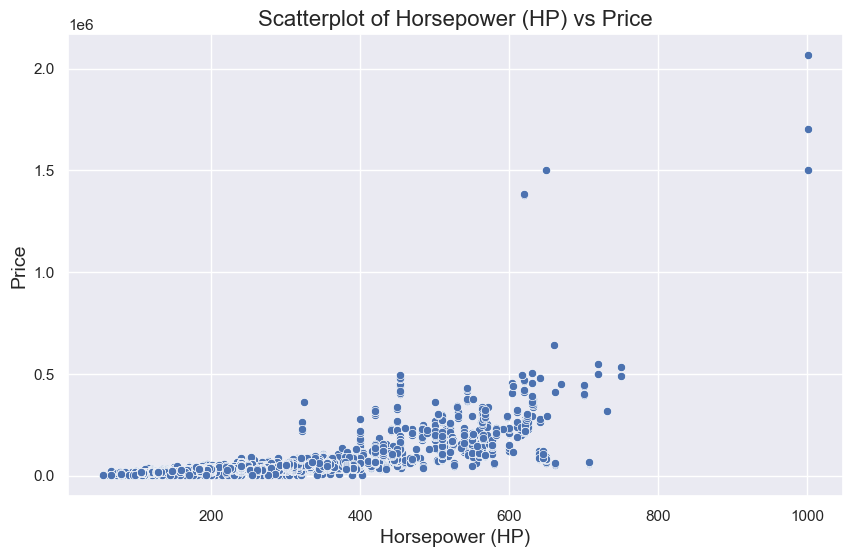

In [49]:
## Your code here - 
# fig, ax = plt.subplots(figsize=(10,6))

# plot scatterplot on hp and price

fig, ax = plt.subplots(figsize=(10, 6))

# Plot scatterplot for HP vs Price
sns.scatterplot(data=df, x='HP', y='Price', ax=ax)

# Set plot title and labels
ax.set_title('Scatterplot of Horsepower (HP) vs Price', fontsize=16)
ax.set_xlabel('Horsepower (HP)', fontsize=14)
ax.set_ylabel('Price', fontsize=14)

# Show the plot
plt.show()


### **`Observation:`**<br>
It is a type of plot or mathematical diagram using Cartesian coordinates to display values for typically two variables for a set of data.<br>
We have plot the scatter plot with x axis as HP and y axis as Price.<br>
The data points between the features should be same either wise it give errors.<br>


## `Plotting Aggregated Values across Categories`


### `Bar Plots - Mean, Median and Count Plots`



Bar plots are used to **display aggregated values** of a variable, rather than entire distributions. This is especially useful when you have a lot of data which is difficult to visualise in a single figure. 

For example, say you want to visualise and *compare the Price across Cylinders*. The ```sns.barplot()``` function can be used to do that.


Text(0, 0.5, 'Average Price')

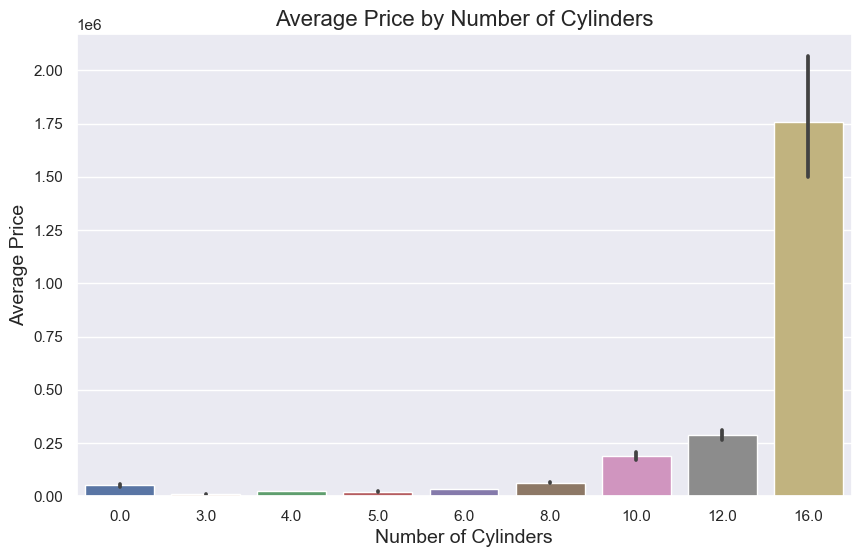

In [50]:
# bar plot with default statistic=mean between Cylinder and Price

plt.figure(figsize=(10, 6))

# Create a bar plot with Cylinder on the x-axis and average Price on the y-axis
sns.barplot(data=df, x='Cylinders', y='Price')

# Set plot title and labels
plt.title('Average Price by Number of Cylinders', fontsize=16)
plt.xlabel('Number of Cylinders', fontsize=14)
plt.ylabel('Average Price', fontsize=14)




### **`Observation:`**<br>
By default, seaborn plots the mean value across categories, though you can plot the count, median, sum etc.<br>
Also, barplot computes and shows the confidence interval of the mean as well.



## `When you want to visualise having a large number of categories, it is helpful to plot the categories across the y-axis.`

### `Let's now drill down into Transmission sub categories.`

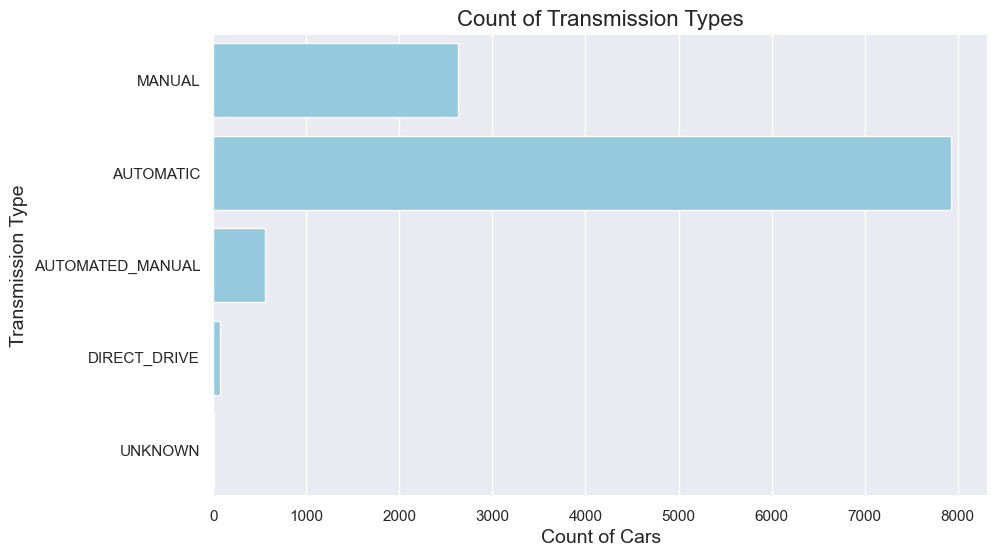

In [51]:
# Plotting categorical variable Transmission across the y-axis

plt.figure(figsize=(10, 6))

# Plot the count of each Transmission type on the y-axis
sns.countplot(data=df, y='Transmission', color='skyblue')

# Set plot title and labels
plt.title('Count of Transmission Types', fontsize=16)
plt.xlabel('Count of Cars', fontsize=14)
plt.ylabel('Transmission Type', fontsize=14)

# Show the plot
plt.show()


These plots looks beutiful isn't it? In Data Analyst life such charts are there unavoidable friend.:)

# `Multivariate Plots`



## `Heatmaps`


A heat map is a two-dimensional representation of information with the help of colors. Heat maps can help the user visualize simple or complex information

Using heatmaps plot the correlation between the features present in the dataset.

                     Year        HP  Cylinders  Number of Doors  highway MPG  \
Year             1.000000  0.336208  -0.034148         0.247574     0.244972   
HP               0.336208  1.000000   0.788433        -0.129278    -0.415452   
Cylinders       -0.034148  0.788433   1.000000        -0.149877    -0.617420   
Number of Doors  0.247574 -0.129278  -0.149877         1.000000     0.114673   
highway MPG      0.244972 -0.415452  -0.617420         0.114673     1.000000   
city mpg         0.188417 -0.446855  -0.598708         0.120682     0.886299   
Popularity       0.085874  0.042499   0.038640        -0.057235    -0.017159   
Price            0.209635  0.659174   0.538712        -0.144925    -0.166631   

                 city mpg  Popularity     Price  
Year             0.188417    0.085874  0.209635  
HP              -0.446855    0.042499  0.659174  
Cylinders       -0.598708    0.038640  0.538712  
Number of Doors  0.120682   -0.057235 -0.144925  
highway MPG      0.886299   -

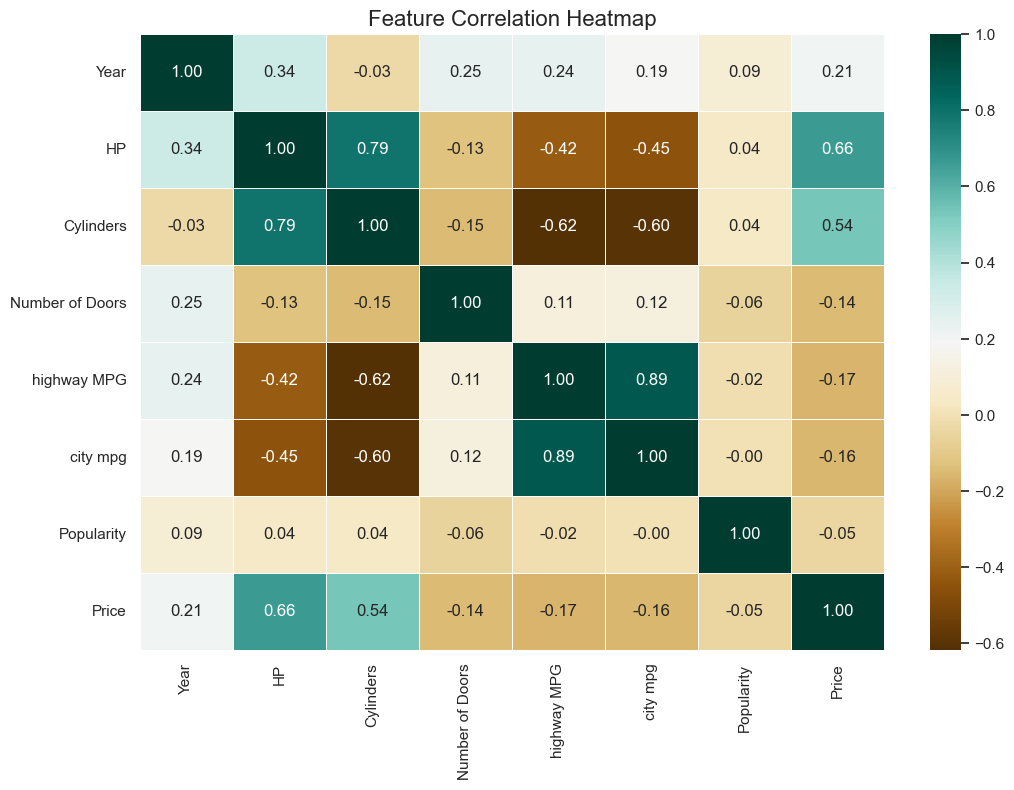

In [52]:
#find the correlation of features of the data 
# corr = 

# print corr
corr = df.corr()

# Print the correlation matrix (optional)
print(corr)

# Set up the figure size
plt.figure(figsize=(12, 8))

# Plot the heatmap with specific settings
sns.heatmap(corr, cmap='BrBG', annot=True, fmt=".2f", linewidths=0.5)

# Set title for the heatmap
plt.title('Feature Correlation Heatmap', fontsize=16)

# Show the plot
plt.show()

### **`Observation:`**<br>
A heatmap contains values representing various shades of the same colour for each value to be plotted. Usually the darker shades of the chart represent higher values than the lighter shade. For a very different value a completely different colour can also be used.


The above heatmap plot shows correlation between various variables in the colored scale of -1 to 1. 
